# RS flavor anarchy (ACPS) ensemble analysis

Forward-only ensemble for the literature-standard RS flavor anarchy setup
(Agashe-Contino-Pomarol-Sundrum 2004 hep-ph/0408134; Csaki-Falkowski-Weiler
0804.1954).  c-values are **fixed** to a hierarchical pattern; anarchic
O(1) Yukawas Y_u, Y_d are drawn iid; the resulting masses, CKM, and
ΔF=2 ratios are computed forward (no optimizer).

## Inputs
Reads `scan_outputs/rs_anarchy_<timestamp>/tile_summary.json` (lightweight)
and `draws.jsonl` only when needed (streamed line-by-line).

## Plots
1. PDG-pass fraction vs M_KK
2. max-ratio percentiles (PDG-passing) vs M_KK
3. Per-draw histogram of M_KK_min (smallest M_KK at which the draw passes
   all five ΔF=2 systems)
4. Cumulative: fraction of PDG-passing anarchic draws allowed at each M_KK

## Headline
*M_KK at 50% acceptance among PDG-passing anarchic NMFV draws is X TeV.*

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path('/n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# *** Set this to the run directory written by run_rs_anarchy.sbatch ***
RUN_DIR = REPO_ROOT / 'scan_outputs' / 'rs_anarchy_20260507T030811'

SUMMARY_PATH = RUN_DIR / 'tile_summary.json'
DRAWS_PATH = RUN_DIR / 'draws.jsonl'

FIG_DIR = RUN_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Run dir:', RUN_DIR)
print('Summary:', SUMMARY_PATH.exists(), SUMMARY_PATH)
print('Draws:  ', DRAWS_PATH.exists(), DRAWS_PATH)

Run dir: /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/rs_anarchy_20260507T030811
Summary: True /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/rs_anarchy_20260507T030811/tile_summary.json
Draws:   True /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/rs_anarchy_20260507T030811/draws.jsonl


## 1. Load tile summary (lightweight)

In [2]:
with open(SUMMARY_PATH) as fh:
    summary = json.load(fh)

config = summary['config']
tiles = summary['tiles']
tiles = sorted(tiles, key=lambda t: t['M_KK_GeV'])
M_KK_TeV = np.array([t['M_KK_GeV'] / 1000.0 for t in tiles])
pdg_frac = np.array([t['pdg_pass_fraction'] for t in tiles])
n_pdg_pass = np.array([t['n_pdg_pass'] for t in tiles])

print('c_Q =', config['c_Q'])
print('c_u =', config['c_u'])
print('c_d =', config['c_d'])
print('xi_KK =', config['xi_KK'])
print()
print('Per-tile summary:')
for t in tiles:
    print(
        f"  M_KK={t['M_KK_GeV']/1000:5.1f} TeV  "
        f"PDG-pass={t['n_pdg_pass']}/{t['n_ok']}  "
        f"frac={t['pdg_pass_fraction']:.2%}"
    )

c_Q = [0.63, 0.57, 0.2]
c_u = [0.66, 0.5, -0.5]
c_d = [0.66, 0.61, 0.55]
xi_KK = 2.4487

Per-tile summary:
  M_KK=  3.0 TeV  PDG-pass=16360/100000  frac=16.36%
  M_KK=  5.0 TeV  PDG-pass=18874/100000  frac=18.87%
  M_KK=  7.0 TeV  PDG-pass=19882/100000  frac=19.88%
  M_KK= 10.0 TeV  PDG-pass=20609/100000  frac=20.61%
  M_KK= 15.0 TeV  PDG-pass=20740/100000  frac=20.74%
  M_KK= 20.0 TeV  PDG-pass=20398/100000  frac=20.40%
  M_KK= 30.0 TeV  PDG-pass=19283/100000  frac=19.28%
  M_KK= 50.0 TeV  PDG-pass=16951/100000  frac=16.95%


## 2. Plot 1 — PDG-pass fraction vs M_KK

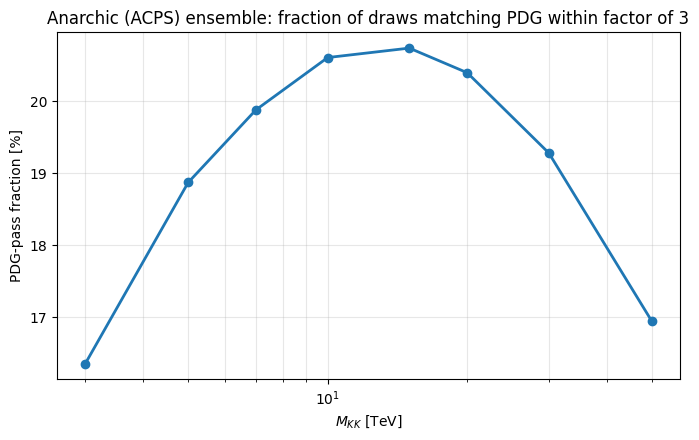

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(M_KK_TeV, pdg_frac * 100.0, 'o-', lw=2, color='C0')
ax.set_xlabel('$M_{KK}$ [TeV]')
ax.set_ylabel('PDG-pass fraction [%]')
ax.set_title('Anarchic (ACPS) ensemble: fraction of draws matching PDG within factor of 3')
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'plot1_pdg_pass_fraction.pdf')
plt.show()

## 3. Plot 2 — max-ratio percentiles (PDG-passing only) vs M_KK

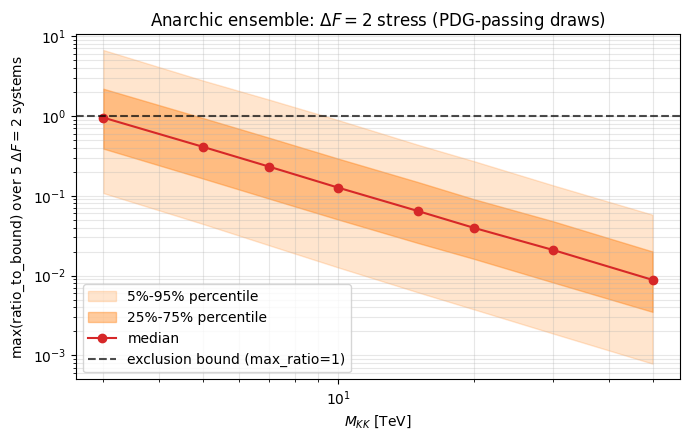

In [4]:
p05 = []
p25 = []
p50 = []
p75 = []
p95 = []
for t in tiles:
    p = t.get('max_ratio_percentiles_pdg')
    if p is None:
        for arr in (p05, p25, p50, p75, p95):
            arr.append(np.nan)
        continue
    p05.append(p['p05'])
    p25.append(p['p25'])
    p50.append(p['p50'])
    p75.append(p['p75'])
    p95.append(p['p95'])
p05, p25, p50, p75, p95 = (np.array(x) for x in (p05, p25, p50, p75, p95))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(M_KK_TeV, p05, p95, alpha=0.2, color='C1', label='5%-95% percentile')
ax.fill_between(M_KK_TeV, p25, p75, alpha=0.4, color='C1', label='25%-75% percentile')
ax.plot(M_KK_TeV, p50, 'o-', color='C3', label='median')
ax.axhline(1.0, color='k', ls='--', alpha=0.7, label='exclusion bound (max_ratio=1)')
ax.set_xlabel('$M_{KK}$ [TeV]')
ax.set_ylabel(r'max(ratio_to_bound) over 5 $\Delta F=2$ systems')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Anarchic ensemble: $\\Delta F=2$ stress (PDG-passing draws)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'plot2_max_ratio_percentiles.pdf')
plt.show()

## 4. Stream the JSONL to compute per-draw M_KK_min

For each anarchic draw, the `max_ratio` scales like $1 / M_{KK}^2$ at fixed Y
and fixed c-values (the Wilson-coefficient prefactor is $1/M_{KK}^2$).  So the
smallest $M_{KK}$ at which that draw would pass the joint $\Delta F = 2$ bound
is

$$ M_{KK}^{min} = M_{KK} \sqrt{\max\text{-ratio}}\,, $$

evaluated at the simulated tile's $M_{KK}$.  This lets us turn each draw into a
scalar minimum-allowed scale.  We extract this **only from PDG-passing draws**
and use the lowest tile (closest to $M_{KK}^{min}$) per draw to avoid double
counting; in practice we just use one tile's draws for the histogram (e.g.
$M_{KK} = 10$ TeV) and rescale.  The cell below streams the JSONL line-by-line
to keep memory low at 800k rows.

In [5]:
# Use the median-tile draws to infer M_KK_min.  Choosing M_KK=10 TeV keeps
# us in the regime where ~17% pass PDG, providing solid statistics for the
# histogram.
TARGET_TILE_TEV = 10.0
TARGET_TILE_GEV = TARGET_TILE_TEV * 1000.0

m_kk_min_tev_pdg = []
max_ratio_pdg = []
with open(DRAWS_PATH) as fh:
    for line in fh:
        try:
            row = json.loads(line)
        except json.JSONDecodeError:
            continue
        if not row.get('ok'):
            continue
        if abs(row['M_KK_GeV'] - TARGET_TILE_GEV) > 1.0:
            continue
        if not row.get('passes_pdg'):
            continue
        ratio = row.get('max_ratio')
        if ratio is None or not np.isfinite(ratio):
            continue
        m_kk_min = TARGET_TILE_TEV * np.sqrt(max(ratio, 1e-30))
        m_kk_min_tev_pdg.append(float(m_kk_min))
        max_ratio_pdg.append(float(ratio))

m_kk_min_tev_pdg = np.array(m_kk_min_tev_pdg)
max_ratio_pdg = np.array(max_ratio_pdg)
print(
    f'PDG-passing draws at {TARGET_TILE_TEV:.0f} TeV: n = {m_kk_min_tev_pdg.size}'
)
if m_kk_min_tev_pdg.size:
    print('M_KK_min percentiles (TeV): p5={:.2f}, p50={:.2f}, p95={:.2f}'.format(
        *np.percentile(m_kk_min_tev_pdg, [5, 50, 95])
    ))

PDG-passing draws at 10 TeV: n = 20609
M_KK_min percentiles (TeV): p5=1.12, p50=3.55, p95=9.41


## 5. Plot 3 — histogram of M_KK_min

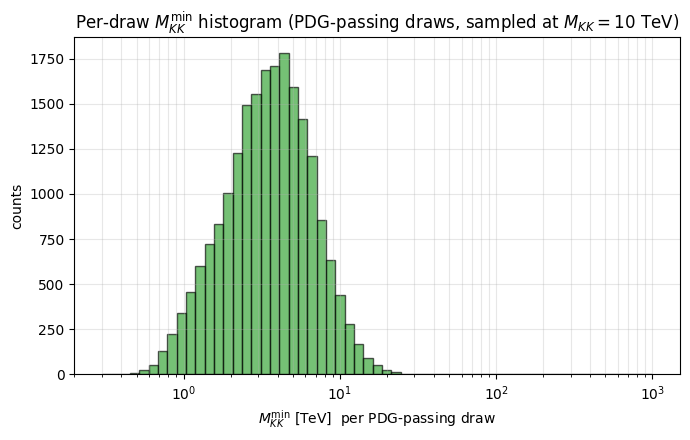

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
if m_kk_min_tev_pdg.size:
    bins = np.logspace(np.log10(0.3), np.log10(1000.0), 60)
    ax.hist(m_kk_min_tev_pdg, bins=bins, alpha=0.65, color='C2', edgecolor='black')
ax.set_xscale('log')
ax.set_xlabel(r'$M_{KK}^{\min}$ [TeV]  per PDG-passing draw')
ax.set_ylabel('counts')
ax.set_title(
    f'Per-draw $M_{{KK}}^{{\\min}}$ histogram '
    f'(PDG-passing draws, sampled at $M_{{KK}} = {TARGET_TILE_TEV:g}$ TeV)'
)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'plot3_m_kk_min_histogram.pdf')
plt.show()

## 6. Plot 4 — cumulative fraction allowed at each M_KK

Reads the per-draw distribution of `M_KK_min`.  At each candidate $M$, the
fraction of PDG-passing draws with $M_{KK}^{min} \le M$ is the fraction
*allowed* if the actual KK scale were $M$.

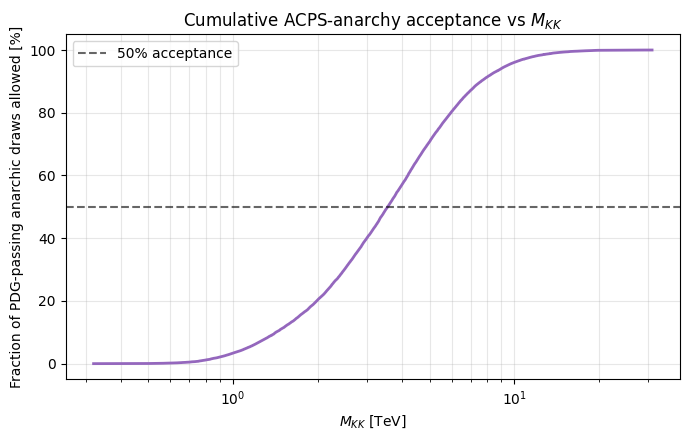


HEADLINE: M_KK at 50% acceptance among PDG-passing anarchic NMFV draws is 3.6 TeV.
          (95% acceptance reached at M_KK = 9.4 TeV.)


In [7]:
if m_kk_min_tev_pdg.size:
    sorted_min = np.sort(m_kk_min_tev_pdg)
    cum_frac = np.arange(1, sorted_min.size + 1) / sorted_min.size
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sorted_min, cum_frac * 100.0, lw=2, color='C4')
    ax.axhline(50.0, ls='--', color='k', alpha=0.6, label='50% acceptance')
    ax.set_xscale('log')
    ax.set_xlabel(r'$M_{KK}$ [TeV]')
    ax.set_ylabel('Fraction of PDG-passing anarchic draws allowed [%]')
    ax.set_title(r'Cumulative ACPS-anarchy acceptance vs $M_{KK}$')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'plot4_cumulative_acceptance.pdf')
    plt.show()

    median_m_kk_tev = float(np.median(sorted_min))
    p95_m_kk_tev = float(np.percentile(sorted_min, 95))
    print()
    print('=' * 60)
    print(
        f'HEADLINE: M_KK at 50% acceptance among PDG-passing anarchic NMFV '
        f'draws is {median_m_kk_tev:.1f} TeV.'
    )
    print(
        f'          (95% acceptance reached at M_KK = {p95_m_kk_tev:.1f} TeV.)'
    )
    print('=' * 60)

## 7. Per-system pass fractions

Sanity check that the dominant constraint is $\epsilon_K$, as standard in
RS-anarchy literature (Csaki-Falkowski-Weiler 0804.1954).

In [8]:
import pandas as pd

rows = []
for t in tiles:
    p = t.get('per_system_pass_fraction_pdg', {})
    rows.append({
        'M_KK_TeV': t['M_KK_GeV'] / 1000.0,
        'PDG_frac': t['pdg_pass_fraction'],
        **{k: float(v) for k, v in p.items()},
    })
df = pd.DataFrame(rows)
df

,M_KK_TeV,PDG_frac,epsilon_K,Delta_m_K,Delta_m_Bd,Delta_m_Bs,Delta_m_D0
0,3.0,0.16360,0.516626,1.0,0.999328,0.999022,0.997677
1,5.0,0.18874,0.766504,1.0,1.000000,1.000000,0.999894
2,7.0,0.19882,0.888643,1.0,1.000000,1.000000,1.000000
3,10.0,0.20609,0.960600,1.0,1.000000,1.000000,1.000000
4,15.0,0.20740,0.991369,1.0,1.000000,1.000000,1.000000
5,20.0,0.20398,0.997500,1.0,1.000000,1.000000,1.000000
6,30.0,0.19283,0.999896,1.0,1.000000,1.000000,1.000000
7,50.0,0.16951,1.000000,1.0,1.000000,1.000000,1.000000
